In [1]:


pip install pandas seaborn matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sc

In [4]:
df = pd.read_csv("WineQT.csv")

In [5]:
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [8]:
df.shape

(1143, 13)

In [9]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [10]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [11]:
df.drop('Id', axis=1, inplace=True)

In [12]:
df.duplicated().value_counts()

False    1018
True      125
Name: count, dtype: int64

In [13]:
df[df.duplicated(keep=False)]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
45,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
46,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
59,8.6,0.490,0.28,1.90,0.110,20.0,136.0,0.99720,2.93,1.95,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1113,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1114,7.8,0.600,0.26,2.00,0.080,31.0,131.0,0.99622,3.21,0.52,9.9,5
1115,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1116,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5


In [14]:
df = df.drop_duplicates().reset_index(drop=True)


<Axes: >

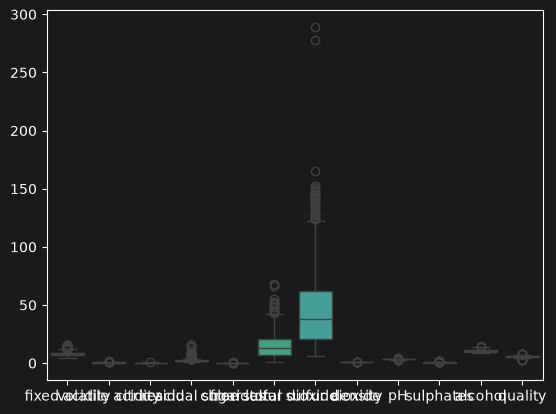

In [15]:
sns.boxplot(data=df)

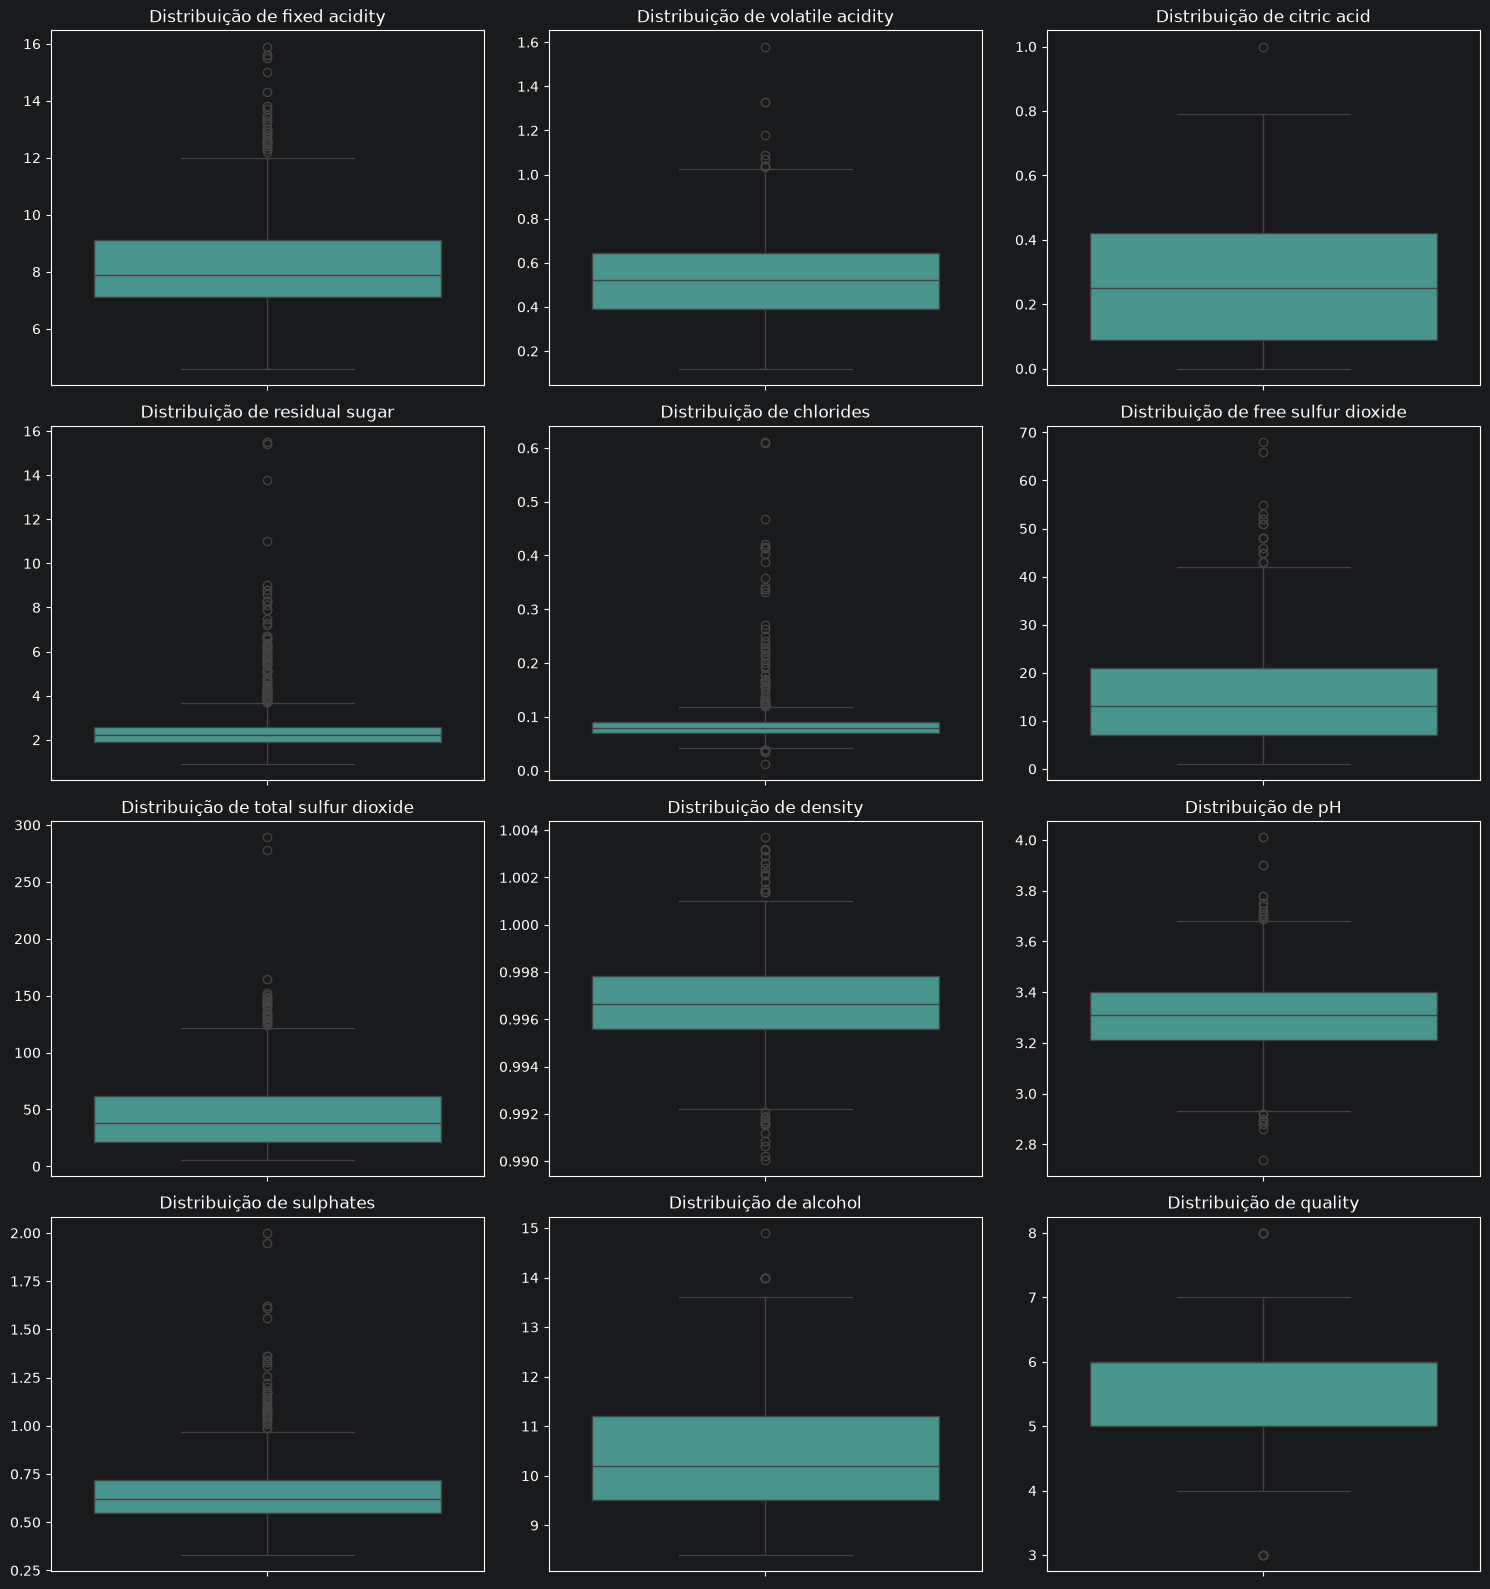

In [16]:

import math

colunas = df.select_dtypes(include=['number']).columns

num_colunas_grid = 3
num_linhas_grid = math.ceil(len(colunas) / num_colunas_grid)

fig, axes = plt.subplots(num_linhas_grid, num_colunas_grid, figsize=(15, 4 * num_linhas_grid))
axes = axes.flatten()  # Transforma a matriz em lista para facilitar o loop

for i, col in enumerate(colunas):
    sns.boxplot(y=df[col], ax=axes[i], color='#3ca197') # Cor similar à do seu gráfico
    axes[i].set_title(f'Distribuição de {col}', fontsize=12)
    axes[i].set_ylabel('')  # Remove rótulo repetido do eixo Y

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [17]:
import numpy as np


# 1. CRIANDO AS COLUNAS TRANSFORMADAS EM LOG
# Mantemos as originais salvas e criamos novas para aplicar o IQR
df['chlorides_log'] = np.log(df['chlorides'])
df['residual_sugar_log'] = np.log(df['residual sugar'])

# 2. DEFININDO OS GRUPOS DE COLUNAS E SEUS RESPECTIVOS MULTIPLICADORES
# Ajuste os nomes das colunas de acordo com o seu dataset real
colunas_simetricas = ['fixed acidity', 'volatile acidity', 'citric acid']  # Exemplo 1.5x
colunas_intermediarias = ['free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']  # Exemplo 3x
colunas_assimetricas_log = ['chlorides_log', 'residual_sugar_log']  # Log + IQR de sua escolha (ex: 1.5x)

# Criamos uma cópia para filtrar as linhas sem perder o DataFrame original



# 3. FUNÇÃO PARA RETORNAR MÁSCARA BOOLEANA DOS OUTLIERS
def obter_mascara_outliers(df_coluna, multiplicador):
    q1 = df_coluna.quantile(0.25)
    q3 = df_coluna.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - multiplicador * iqr
    limite_superior = q3 + multiplicador * iqr

    # Retorna True onde o dado é considerado um outlier
    return (df_coluna < limite_inferior) | (df_coluna > limite_superior)


# 4. APLICANDO O FILTRO EM CADEIA
outliers_totais = pd.Series(False, index=df.index)

# Aplicando 1.5x nas simétricas
for col in colunas_simetricas:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 1.5)

# Aplicando 3.0x nas intermediárias
for col in colunas_intermediarias:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 3.0)

# Aplicando na versão LOG das assimétricas (sugestão: 1.5x ou 3.0x conforme seu teste)
for col in colunas_assimetricas_log:
    outliers_totais = outliers_totais | obter_mascara_outliers(df[col], 3.0)

# 5. REMOVENDO OS OUTLIERS DO DATASET
df_final = df[~outliers_totais]

# Verificando o tamanho final do dataset
print(f"Formato original: {df.shape}")
print(f"Formato após a remoção híbrida: {df_final.shape}")
print(f"Total de linhas removidas: {df.shape[0] - df_final.shape[0]}")


Formato original: (1018, 14)
Formato após a remoção híbrida: (922, 14)
Total de linhas removidas: 96


In [18]:
df_final = df_final.copy()
df_final['faixa_qualidade'] = pd.cut(df_final['quality'], bins=[2, 5, 6, 8], labels=['baixa', 'media', 'alta'], ordered=True)
df_final['razao_so2_livre'] = df_final['free sulfur dioxide'] / df_final['total sulfur dioxide']

In [19]:
df_final['faixa_qualidade'].value_counts()

faixa_qualidade
baixa    429
media    369
alta     124
Name: count, dtype: int64

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
AXIS = "#c3c2b7"
BLUE = "#2a78d6"
RAMP = {"baixa": "#86b6ef", "media": "#2a78d6", "alta": "#104281"}
ROTULO_FAIXA = {"baixa": "baixa (3–5)", "media": "média (6)", "alta": "alta (7–8)"}

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "font.family": "DejaVu Sans",
    "text.color": INK,
    "axes.labelcolor": INK2,
    "axes.edgecolor": AXIS,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "legend.fontsize": 9,
})


def estilo(ax, eixo_grade="y"):
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    ax.spines["left"].set_color(AXIS)
    ax.spines["bottom"].set_color(AXIS)
    ax.grid(axis=eixo_grade, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


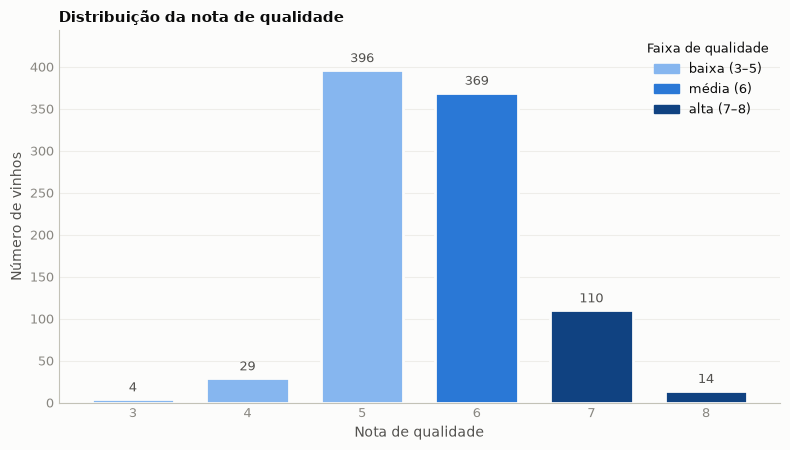

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.6))
contagem = df_final["quality"].value_counts().sort_index()
cores = [RAMP["baixa"] if q <= 5 else RAMP["media"] if q == 6 else RAMP["alta"] for q in contagem.index]
ax.bar(contagem.index, contagem.values, width=0.72, color=cores, edgecolor=SURFACE, linewidth=2)
for x, y in zip(contagem.index, contagem.values):
    ax.text(x, y + 6, str(y), ha="center", va="bottom", fontsize=9, color=INK2)
ax.set_xlabel("Nota de qualidade")
ax.set_ylabel("Número de vinhos")
ax.set_title("Distribuição da nota de qualidade", loc="left")
ax.set_xticks(contagem.index)
ax.set_ylim(0, contagem.max() * 1.12)
estilo(ax)
ax.legend(
    handles=[Patch(color=RAMP[k], label=ROTULO_FAIXA[k]) for k in ("baixa", "media", "alta")],
    title="Faixa de qualidade",
    title_fontsize=9,
    loc="upper right",
)
fig.tight_layout()
plt.show()

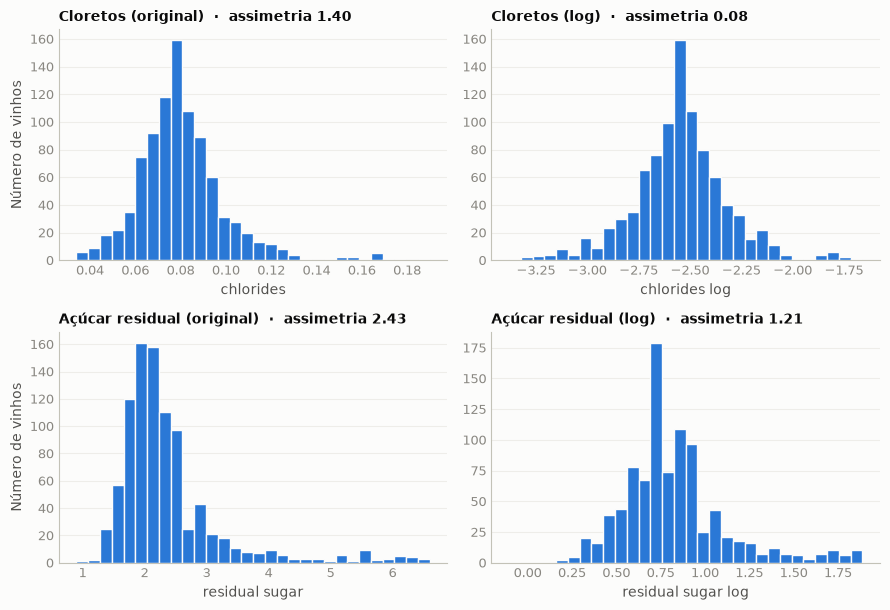

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6.2))
pares = [
    ("chlorides", "Cloretos (original)", "chlorides_log", "Cloretos (log)"),
    ("residual sugar", "Açúcar residual (original)", "residual_sugar_log", "Açúcar residual (log)"),
]
for i, (original, titulo_original, versao_log, titulo_log) in enumerate(pares):
    for j, (coluna, titulo) in enumerate([(original, titulo_original), (versao_log, titulo_log)]):
        ax = axes[i, j]
        ax.hist(df_final[coluna], bins=30, color=BLUE, edgecolor=SURFACE, linewidth=1)
        ax.set_title(f"{titulo}  ·  assimetria {df_final[coluna].skew():.2f}", loc="left", fontsize=10)
        ax.set_ylabel("Número de vinhos" if j == 0 else "")
        ax.set_xlabel(coluna.replace("_", " "))
        estilo(ax)
fig.tight_layout()
plt.show()

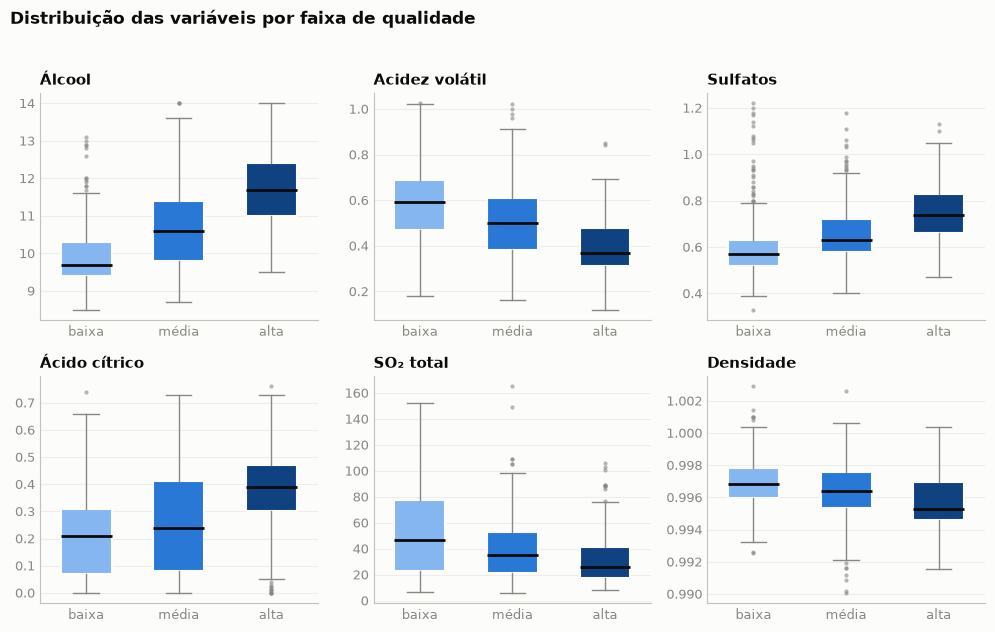

In [23]:
variaveis_box = [
    ("alcohol", "Álcool"),
    ("volatile acidity", "Acidez volátil"),
    ("sulphates", "Sulfatos"),
    ("citric acid", "Ácido cítrico"),
    ("total sulfur dioxide", "SO₂ total"),
    ("density", "Densidade"),
]
ordem_faixas = ["baixa", "media", "alta"]
fig, axes = plt.subplots(2, 3, figsize=(10, 6.4))
for ax, (coluna, nome) in zip(axes.ravel(), variaveis_box):
    dados = [df_final.loc[df_final["faixa_qualidade"] == f, coluna] for f in ordem_faixas]
    caixas = ax.boxplot(
        dados,
        patch_artist=True,
        widths=0.55,
        showfliers=True,
        flierprops=dict(marker="o", markersize=3, markerfacecolor=MUTED, markeredgecolor="none", alpha=0.6),
        medianprops=dict(color=INK, linewidth=2),
        whiskerprops=dict(color=MUTED, linewidth=1),
        capprops=dict(color=MUTED, linewidth=1),
        boxprops=dict(linewidth=1.5, edgecolor=SURFACE),
    )
    for caixa, f in zip(caixas["boxes"], ordem_faixas):
        caixa.set_facecolor(RAMP[f])
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["baixa", "média", "alta"])
    ax.set_title(nome, loc="left")
    estilo(ax)
fig.suptitle("Distribuição das variáveis por faixa de qualidade", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

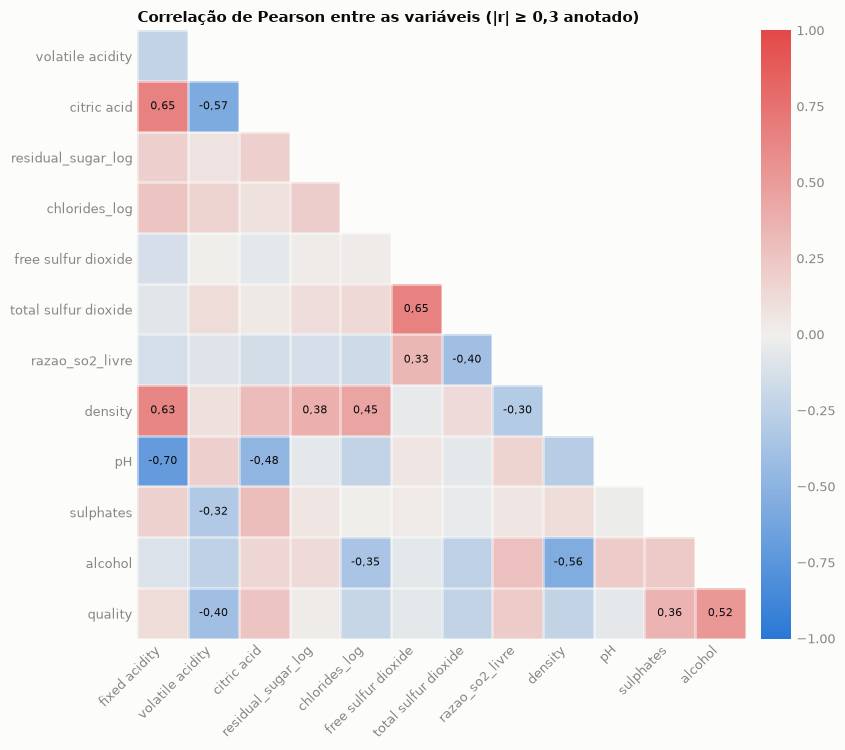

In [24]:
colunas_corr = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual_sugar_log",
    "chlorides_log",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "razao_so2_livre",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality",
]
corr = df_final[colunas_corr].corr().iloc[1:, :-1]
rotulos_linhas = colunas_corr[1:]
rotulos_colunas = colunas_corr[:-1]
mapa_cores = LinearSegmentedColormap.from_list("divergente", ["#2a78d6", "#f0efec", "#e34948"])
n = len(rotulos_linhas)
mascara = np.triu(np.ones((n, n), dtype=bool), k=1)
matriz = np.ma.array(corr.values, mask=mascara)
fig, ax = plt.subplots(figsize=(9, 7.6))
imagem = ax.imshow(matriz, cmap=mapa_cores, vmin=-1, vmax=1)
for i in range(n):
    for j in range(n):
        valor = corr.values[i, j]
        if not mascara[i, j] and abs(valor) >= 0.3:
            ax.text(j, i, f"{valor:.2f}".replace(".", ","), ha="center", va="center", fontsize=8,
                    color="#ffffff" if abs(valor) >= 0.7 else INK)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(rotulos_colunas, rotation=45, ha="right")
ax.set_yticklabels(rotulos_linhas)
for borda in ax.spines.values():
    borda.set_visible(False)
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="both", length=0)
ax.set_title("Correlação de Pearson entre as variáveis (|r| ≥ 0,3 anotado)", loc="left")
barra = fig.colorbar(imagem, ax=ax, fraction=0.04, pad=0.02)
barra.outline.set_visible(False)
barra.ax.tick_params(length=0)
fig.tight_layout()
plt.show()

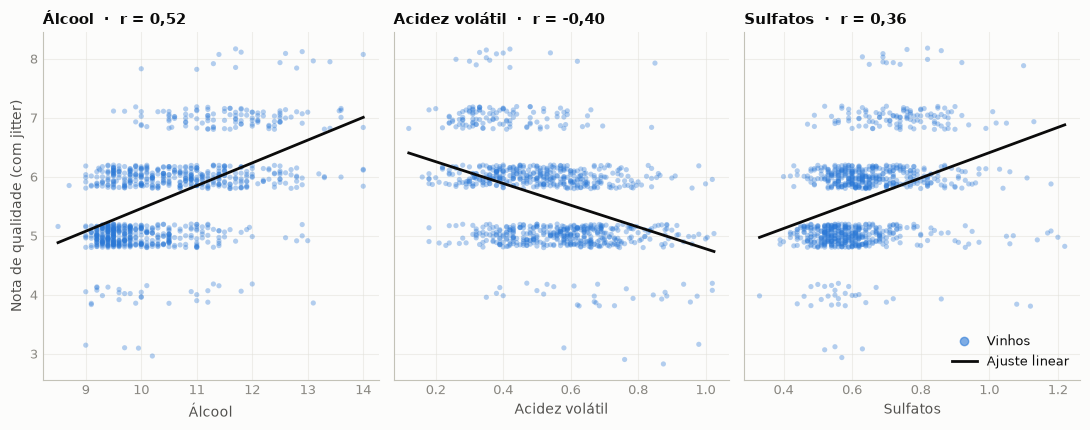

In [25]:
rng = np.random.default_rng(42)
principais = [("alcohol", "Álcool"), ("volatile acidity", "Acidez volátil"), ("sulphates", "Sulfatos")]
fig, axes = plt.subplots(1, 3, figsize=(11, 4.4), sharey=True)
for ax, (coluna, nome) in zip(axes, principais):
    y_jitter = df_final["quality"] + rng.uniform(-0.2, 0.2, len(df_final))
    ax.scatter(df_final[coluna], y_jitter, s=14, color=BLUE, alpha=0.35, edgecolor="none")
    inclinacao, intercepto = np.polyfit(df_final[coluna], df_final["quality"], 1)
    xs = np.linspace(df_final[coluna].min(), df_final[coluna].max(), 50)
    ax.plot(xs, inclinacao * xs + intercepto, color=INK, linewidth=2)
    r = df_final[coluna].corr(df_final["quality"])
    ax.set_title(f"{nome}  ·  r = {r:.2f}".replace(".", ","), loc="left")
    ax.set_xlabel(nome)
    estilo(ax, eixo_grade="both")
axes[0].set_ylabel("Nota de qualidade (com jitter)")
axes[0].set_yticks(range(3, 9))
axes[-1].legend(
    handles=[
        Line2D([0], [0], marker="o", linestyle="", color=BLUE, alpha=0.6, markersize=6, label="Vinhos"),
        Line2D([0], [0], color=INK, linewidth=2, label="Ajuste linear"),
    ],
    loc="lower right",
)
fig.tight_layout()
plt.show()

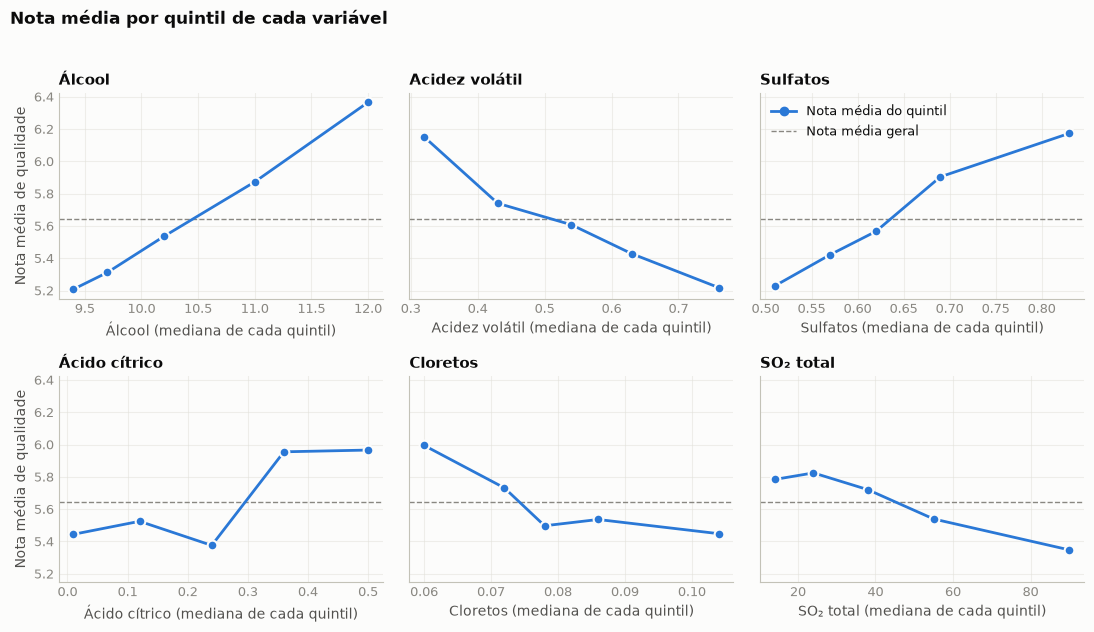

In [26]:
perfis = [
    ("alcohol", "Álcool"),
    ("volatile acidity", "Acidez volátil"),
    ("sulphates", "Sulfatos"),
    ("citric acid", "Ácido cítrico"),
    ("chlorides", "Cloretos"),
    ("total sulfur dioxide", "SO₂ total"),
]
media_geral = df_final["quality"].mean()
fig, axes = plt.subplots(2, 3, figsize=(11, 6.4), sharey=True)
for ax, (coluna, nome) in zip(axes.ravel(), perfis):
    quintis = pd.qcut(df_final[coluna], 5, duplicates="drop")
    resumo = df_final.groupby(quintis, observed=True).agg(x=(coluna, "median"), media=("quality", "mean"))
    ax.axhline(media_geral, color=MUTED, linewidth=1, linestyle="--")
    ax.plot(resumo["x"], resumo["media"], color=BLUE, linewidth=2, marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    ax.set_title(nome, loc="left")
    ax.set_xlabel(f"{nome} (mediana de cada quintil)")
    estilo(ax, eixo_grade="both")
axes[0, 0].set_ylabel("Nota média de qualidade")
axes[1, 0].set_ylabel("Nota média de qualidade")
axes[0, 2].legend(
    handles=[
        Line2D([0], [0], color=BLUE, linewidth=2, marker="o", markersize=6, label="Nota média do quintil"),
        Line2D([0], [0], color=MUTED, linewidth=1, linestyle="--", label="Nota média geral"),
    ],
    loc="upper left",
)
fig.suptitle("Nota média por quintil de cada variável", x=0.01, ha="left", fontsize=12, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3. Insights iniciais e formulação das hipóteses

A análise exploratória sugere que `alcohol`, `volatile acidity` e `sulphates` são variáveis relevantes para investigar a qualidade do vinho. A variável `quality` será mantida em sua escala numérica para a regressão linear, enquanto `faixa_qualidade` será usada para comparar grupos.

As análises abaixo avaliam se as diferenças observadas na exploração dos dados são acompanhadas por evidências estatísticas. O nível de significância adotado será de 5% (α = 0,05). Os resultados indicam associação estatística, não necessariamente causalidade.


### Hipótese 1 — A distribuição de álcool difere entre as faixas de qualidade?

**Pergunta estatística:** a distribuição de `alcohol` é igual nas faixas baixa, média e alta de qualidade?

- **H₀:** as distribuições de álcool são iguais entre as três faixas de qualidade.
- **H₁:** pelo menos uma faixa apresenta distribuição de álcool diferente.
- **Teste escolhido:** Kruskal–Wallis, adequado para comparar três grupos independentes sem exigir normalidade das distribuições.


In [37]:
from scipy import stats


alpha = 0.05
ordem_faixas = ["baixa", "media", "alta"]

grupos_alcohol = [
    df_final.loc[df_final["faixa_qualidade"] == faixa, "alcohol"].dropna()
    for faixa in ordem_faixas
]

resultado_kw_alcohol = stats.kruskal(*grupos_alcohol)
resumo_alcohol = df_final.groupby("faixa_qualidade", observed=True)["alcohol"].agg(
    ["count", "mean", "median", "std"]
)

display(resumo_alcohol)
print(f"Kruskal-Wallis: H={resultado_kw_alcohol.statistic:.4f}, p-valor={resultado_kw_alcohol.pvalue:.6g}")
print("Decisão:", "Rejeitar H0" if resultado_kw_alcohol.pvalue < alpha else "Não rejeitar H0")


,count,mean,median,std
faixa_qualidade,,,,
baixa,429,9.921795,9.7,0.743639
media,369,10.699548,10.6,1.046572
alta,124,11.660618,11.7,0.982094


Kruskal-Wallis: H=270.4947, p-valor=1.8316e-59
Decisão: Rejeitar H0


### Hipótese 2 — A acidez volátil difere entre as faixas de qualidade?

**Pergunta estatística:** a distribuição de `volatile acidity` é igual nas faixas baixa, média e alta?

- **H₀:** as distribuições de acidez volátil são iguais entre as três faixas.
- **H₁:** pelo menos uma faixa apresenta distribuição diferente.
- **Teste escolhido:** Kruskal–Wallis, para comparar os três grupos independentes.


In [38]:
grupos_acidez = [
    df_final.loc[df_final["faixa_qualidade"] == faixa, "volatile acidity"].dropna()
    for faixa in ordem_faixas
]

resultado_kw_acidez = stats.kruskal(*grupos_acidez)
resumo_acidez = df_final.groupby("faixa_qualidade", observed=True)["volatile acidity"].agg(
    ["count", "mean", "median", "std"]
)

display(resumo_acidez)
print(f"Kruskal-Wallis: H={resultado_kw_acidez.statistic:.4f}, p-valor={resultado_kw_acidez.pvalue:.6g}")
print("Decisão:", "Rejeitar H0" if resultado_kw_acidez.pvalue < alpha else "Não rejeitar H0")


,count,mean,median,std
faixa_qualidade,,,,
baixa,429,0.592517,0.59,0.165812
media,369,0.507087,0.50,0.162564
alta,124,0.397379,0.37,0.128678


Kruskal-Wallis: H=144.2866, p-valor=4.66192e-32
Decisão: Rejeitar H0


### Hipótese 3 — Os níveis de sulfatos diferem entre as faixas de qualidade?

**Pergunta estatística:** a distribuição de `sulphates` é igual nas faixas baixa, média e alta?

- **H₀:** as distribuições de sulfatos são iguais entre as três faixas.
- **H₁:** pelo menos uma faixa apresenta distribuição diferente.
- **Teste escolhido:** Kruskal–Wallis, para comparar os três grupos independentes.


In [29]:
grupos_sulfatos = [
    df_final.loc[df_final["faixa_qualidade"] == faixa, "sulphates"].dropna()
    for faixa in ordem_faixas
]

resultado_kw_sulfatos = stats.kruskal(*grupos_sulfatos)
resumo_sulfatos = df_final.groupby("faixa_qualidade", observed=True)["sulphates"].agg(
    ["count", "mean", "median", "std"]
)

display(resumo_sulfatos)
print(f"Kruskal-Wallis: H={resultado_kw_sulfatos.statistic:.4f}, p-valor={resultado_kw_sulfatos.pvalue:.6g}")
print("Decisão:", "Rejeitar H0" if resultado_kw_sulfatos.pvalue < alpha else "Não rejeitar H0")


,count,mean,median,std
faixa_qualidade,,,,
baixa,429,0.597995,0.57,0.126508
media,369,0.660379,0.63,0.123021
alta,124,0.746210,0.74,0.124460


Kruskal-Wallis: H=168.6355, p-valor=2.40579e-37
Decisão: Rejeitar H0


### Comparações complementares — Quais faixas diferem entre si?

Quando o teste de Kruskal–Wallis aponta diferença estatística, ele não identifica sozinho quais grupos diferem. Por isso, serão realizadas comparações par a par com Mann–Whitney U. A correção de Holm controla o aumento do risco de falsos positivos causado pelas comparações múltiplas.


In [30]:
from itertools import combinations

def comparacoes_pareadas(coluna):
    comparacoes = []
    for faixa_a, faixa_b in combinations(ordem_faixas, 2):
        a = df_final.loc[df_final["faixa_qualidade"] == faixa_a, coluna].dropna()
        b = df_final.loc[df_final["faixa_qualidade"] == faixa_b, coluna].dropna()
        teste = stats.mannwhitneyu(a, b, alternative="two-sided")
        comparacoes.append({
            "variavel": coluna,
            "grupo_1": faixa_a,
            "grupo_2": faixa_b,
            "U": teste.statistic,
            "p_valor": teste.pvalue
        })
    tabela = pd.DataFrame(comparacoes)
    p = tabela["p_valor"].to_numpy()
    ordem = np.argsort(p)
    p_ajustado = np.empty(len(p))
    m = len(p)
    limite = 0.0
    for pos, idx in enumerate(ordem):
        valor = min(1.0, (m - pos) * p[idx])
        limite = max(limite, valor)
        p_ajustado[idx] = limite
    tabela["p_valor_holm"] = p_ajustado
    tabela["decisao_5%"] = np.where(tabela["p_valor_holm"] < alpha, "Rejeitar H0", "Não rejeitar H0")
    return tabela

comparacoes_principais = pd.concat([
    comparacoes_pareadas("alcohol"),
    comparacoes_pareadas("volatile acidity"),
    comparacoes_pareadas("sulphates")
], ignore_index=True)

display(comparacoes_principais)


,variavel,grupo_1,grupo_2,U,p_valor,p_valor_holm,decisao_5%
0,alcohol,baixa,media,42294.5,6.317731e-30,1.263546e-29,Rejeitar H0
1,alcohol,baixa,alta,4250.0,3.009875e-46,9.029625e-46,Rejeitar H0
2,alcohol,media,alta,11375.0,5.091372e-17,5.091372e-17,Rejeitar H0
3,volatile acidity,baixa,media,102188.0,1.276408e-12,2.552816e-12,Rejeitar H0
4,volatile acidity,baixa,alta,44145.5,4.146751e-29,1.244025e-28,Rejeitar H0
5,volatile acidity,media,alta,32360.5,4.841767e-12,4.841767e-12,Rejeitar H0
6,sulphates,baixa,media,50825.5,2.564738e-18,5.129475e-18,Rejeitar H0
7,sulphates,baixa,alta,8737.5,4.080815e-30,1.224244e-29,Rejeitar H0
8,sulphates,media,alta,13439.5,6.013234e-12,6.013234e-12,Rejeitar H0


### Intervalos de confiança — Diferença de médias entre qualidade alta e baixa

**Pergunta estatística:** qual é a diferença média observada em álcool e acidez volátil entre os grupos de qualidade alta e baixa?

Será utilizado um intervalo de confiança bootstrap de 95% para a diferença entre médias (alta menos baixa). O intervalo descreve a incerteza da diferença estimada; se não incluir zero, isso é compatível com uma diferença entre as médias ao nível de 5%. A interpretação deve considerar que os dados são observacionais.


In [31]:
def ic_bootstrap_diferenca_medias(coluna, grupo_alto="alta", grupo_baixo="baixa", n_boot=5000, seed=42):
    alto = df_final.loc[df_final["faixa_qualidade"] == grupo_alto, coluna].dropna().to_numpy()
    baixo = df_final.loc[df_final["faixa_qualidade"] == grupo_baixo, coluna].dropna().to_numpy()
    rng = np.random.default_rng(seed)
    diferencas = np.empty(n_boot)
    for i in range(n_boot):
        amostra_alta = rng.choice(alto, size=len(alto), replace=True)
        amostra_baixa = rng.choice(baixo, size=len(baixo), replace=True)
        diferencas[i] = amostra_alta.mean() - amostra_baixa.mean()
    return {
        "variavel": coluna,
        "media_baixa": baixo.mean(),
        "media_alta": alto.mean(),
        "diferenca_alta_menos_baixa": alto.mean() - baixo.mean(),
        "ic95_inferior": np.quantile(diferencas, 0.025),
        "ic95_superior": np.quantile(diferencas, 0.975)
    }

intervalos_confianca = pd.DataFrame([
    ic_bootstrap_diferenca_medias("alcohol"),
    ic_bootstrap_diferenca_medias("volatile acidity")
])
display(intervalos_confianca)


,variavel,media_baixa,media_alta,diferenca_alta_menos_baixa,ic95_inferior,ic95_superior
0,alcohol,9.921795,11.660618,1.738823,1.551947,1.922994
1,volatile acidity,0.592517,0.397379,-0.195138,-0.222312,-0.165925


### Hipótese 4 — Existe associação monotônica entre as variáveis principais e a nota `quality`?

**Pergunta estatística:** existe associação monotônica entre `quality` e cada uma das variáveis `alcohol`, `volatile acidity` e `sulphates`?

- **H₀:** a correlação de Spearman entre a variável analisada e `quality` é zero.
- **H₁:** a correlação de Spearman é diferente de zero.
- **Teste escolhido:** correlação de Spearman, que avalia associação monotônica e não exige relação linear nem normalidade das variáveis.


In [32]:
resultados_spearman = []
for coluna in ["alcohol", "volatile acidity", "sulphates"]:
    rho, p_valor = stats.spearmanr(df_final[coluna], df_final["quality"], nan_policy="omit")
    resultados_spearman.append({
        "variavel": coluna,
        "rho_spearman": rho,
        "p_valor": p_valor,
        "decisao_5%": "Rejeitar H0" if p_valor < alpha else "Não rejeitar H0"
    })

tabela_spearman = pd.DataFrame(resultados_spearman)
display(tabela_spearman)


,variavel,rho_spearman,p_valor,decisao_5%
0,alcohol,0.523139,6.615948e-66,Rejeitar H0
1,volatile acidity,-0.392688,2.320484e-35,Rejeitar H0
2,sulphates,0.419730,1.200136e-40,Rejeitar H0


## 4. Modelo de regressão linear múltipla

A variável dependente será `quality` em escala numérica, para atender ao objetivo de estimar e prever valores. As variáveis explicativas iniciais serão `alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `density` e `total sulfur dioxide`.

O modelo será ajustado por mínimos quadrados ordinários (OLS). Serão avaliados os coeficientes, p-valores, intervalos de confiança de 95%, R² e R² ajustado. A interpretação dos coeficientes será feita mantendo constantes as demais variáveis incluídas no modelo.


### Hipótese 5 — As características químicas explicam parte da variação de `quality`?

**Pergunta estatística:** o conjunto de variáveis explicativas apresenta associação linear estatisticamente significativa com `quality`?

- **H₀:** todos os coeficientes das variáveis explicativas são iguais a zero.
- **H₁:** pelo menos um coeficiente é diferente de zero.
- **Teste escolhido:** teste F global do modelo de regressão linear múltipla.


In [33]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

variaveis_modelo = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "density",
    "total sulfur dioxide"
]

dados_modelo = df_final[variaveis_modelo + ["quality"]].dropna()
X = sm.add_constant(dados_modelo[variaveis_modelo])
y = dados_modelo["quality"]

modelo_ols = sm.OLS(y, X).fit()
print(modelo_ols.summary())
print("\nDecisão do teste F global:", "Rejeitar H0" if modelo_ols.f_pvalue < alpha else "Não rejeitar H0")


                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     96.51
Date:                Wed, 07 Oct 2026   Prob (F-statistic):           6.01e-94
Time:                        11:02:03   Log-Likelihood:                -882.10
No. Observations:                 922   AIC:                             1778.
Df Residuals:                     915   BIC:                             1812.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    5.6486 

### Avaliação preditiva em conjunto de teste

Para avaliar a capacidade preditiva fora dos dados usados no ajuste, será separado um conjunto de teste. As métricas principais serão MAE, RMSE e R². A regressão linear fornece previsões numéricas de `quality`; como a nota é discreta e limitada, previsões fracionárias são esperadas e não devem ser interpretadas como notas observadas exatas.


In [34]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    dados_modelo[variaveis_modelo],
    dados_modelo["quality"],
    test_size=0.20,
    random_state=42
)

X_treino_ols = sm.add_constant(X_treino, has_constant="add")
X_teste_ols = sm.add_constant(X_teste, has_constant="add")

modelo_treino = sm.OLS(y_treino, X_treino_ols).fit()
previsoes = modelo_treino.predict(X_teste_ols)

metricas_modelo = pd.DataFrame([{
    "MAE": mean_absolute_error(y_teste, previsoes),
    "RMSE": np.sqrt(mean_squared_error(y_teste, previsoes)),
    "R2_teste": r2_score(y_teste, previsoes),
    "R2_ajustado_treino": modelo_treino.rsquared_adj
}])

display(metricas_modelo)


,MAE,RMSE,R2_teste,R2_ajustado_treino
0,0.487839,0.636996,0.321248,0.394678


## 5. Observações para interpretar os resultados

- Um p-valor abaixo de 0,05 leva à rejeição da hipótese nula no teste correspondente; isso não mede o tamanho nem a importância prática do efeito.
- Kruskal–Wallis identifica diferença entre pelo menos dois grupos, mas não aponta sozinho quais grupos diferem. Para isso, foram incluídas comparações par a par com correção de Holm.
- Correlações e regressões com dados observacionais indicam associação, não causalidade.
- A remoção de outliers pode alterar a composição da amostra e os resultados. As conclusões devem ser apresentadas como referentes à base tratada, e a decisão de remover observações precisa ser justificada.
- O modelo linear deve ser avaliado também quanto aos resíduos, linearidade, homocedasticidade e multicolinearidade antes de se fazerem afirmações fortes sobre os coeficientes.
- Para o dashboard, apresentar gráficos, estimativas, intervalos e resultados dos testes sem frases que entreguem diretamente a interpretação, permitindo que o usuário explore os resultados.


### Validação dos pressupostos e inferência robusta

A análise dos resíduos complementa o teste F e as métricas preditivas. O teste de Breusch–Pagan avalia a homocedasticidade. Caso H₀ seja rejeitada, os erros-padrão convencionais do OLS podem ser inadequados para a inferência; por isso, serão apresentados erros-padrão robustos HC3.

Também será calculado o VIF para verificar multicolinearidade entre as variáveis explicativas.

In [35]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

modelo_robusto = modelo_ols.get_robustcov_results(cov_type="HC3")

tabela_coeficientes_robusta = pd.DataFrame({
    "variavel": ["Intercepto"] + variaveis_modelo,
    "coeficiente": modelo_robusto.params,
    "erro_padrao_HC3": modelo_robusto.bse,
    "p_valor_HC3": modelo_robusto.pvalues,
    "IC95_inferior": modelo_robusto.conf_int()[:, 0],
    "IC95_superior": modelo_robusto.conf_int()[:, 1]
})

display(tabela_coeficientes_robusta)
print(f"R² = {modelo_ols.rsquared:.4f}")
print(f"R² ajustado = {modelo_ols.rsquared_adj:.4f}")
print(f"p-valor F = {modelo_robusto.f_pvalue:.6g}")

bp = het_breuschpagan(modelo_ols.resid, modelo_ols.model.exog)
resultado_breusch_pagan = pd.DataFrame({
    "estatistica": ["LM", "F"],
    "estatistica_teste": [bp[0], bp[2]],
    "p_valor": [bp[1], bp[3]]
})
display(resultado_breusch_pagan)

tabela_vif = pd.DataFrame({
    "variavel": variaveis_modelo,
    "VIF": [variance_inflation_factor(dados_modelo[variaveis_modelo].values, i) for i in range(len(variaveis_modelo))]
})
display(tabela_vif)

,variavel,coeficiente,erro_padrao_HC3,p_valor_HC3,IC95_inferior,IC95_superior
0,Intercepto,5.648646,18.082518,7.548217e-01,-29.839382,41.136673
1,alcohol,0.291559,0.030670,1.681785e-20,0.231367,0.351751
2,volatile acidity,-0.978672,0.170883,1.384916e-08,-1.314040,-0.643303
3,sulphates,1.151163,0.205932,2.996514e-08,0.747009,1.555317
4,citric acid,0.124956,0.161961,4.405980e-01,-0.192902,0.442815
5,density,-3.201015,18.017818,8.590307e-01,-38.562064,32.160035
6,total sulfur dioxide,-0.002563,0.000661,1.117090e-04,-0.003859,-0.001267


R² = 0.3876
R² ajustado = 0.3836
p-valor F = 2.53082e-94


,estatistica,estatistica_teste,p_valor
0,LM,30.908750,0.000026
1,F,5.289676,0.000023


,variavel,VIF
0,alcohol,1.985790
1,volatile acidity,1.796589
2,sulphates,1.246325
3,citric acid,2.079467
4,density,2.151239
5,total sulfur dioxide,1.100127


### Diagnóstico visual dos resíduos

O gráfico de resíduos versus valores ajustados é usado para procurar padrões sistemáticos e variação não constante. O Q-Q plot auxilia na avaliação visual da aproximação dos resíduos à normalidade. Esses gráficos são diagnósticos, não substituem a análise estatística anterior.

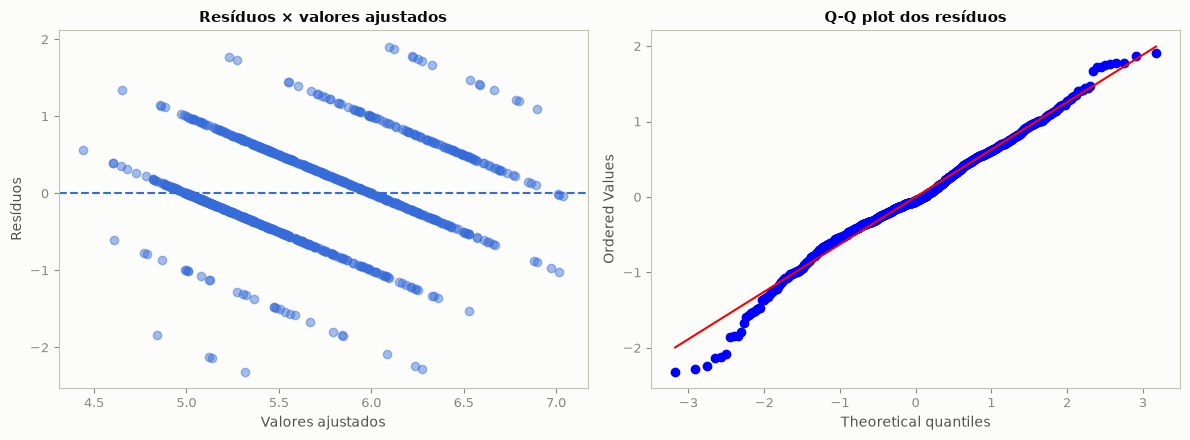

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(modelo_ols.fittedvalues, modelo_ols.resid, alpha=0.45)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Valores ajustados")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos × valores ajustados")

stats.probplot(modelo_ols.resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot dos resíduos")

plt.tight_layout()
plt.show()

### Conclusão da regressão

O teste F avalia o modelo como um conjunto e não implica que todos os coeficientes individuais sejam significativos. Os coeficientes devem ser interpretados mantendo as demais variáveis constantes. Como os dados são observacionais, as relações encontradas são associativas e não causais.

Se o teste de Breusch–Pagan rejeitar H₀, a inferência individual deve ser baseada nos resultados HC3. VIFs elevados indicam que a interpretação isolada de alguns coeficientes requer cautela.